<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part IV · Preparing Data &nbsp;|&nbsp; Chapter 20</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Handling Missing Data <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos: surface hidden missingness, count the cost of deletion, watch mean imputation quietly shrink the variance, impute with KNN and MICE, and do it all without leaking test data.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Surface the gaps | sentinel to NaN, count and chart missingness |
| 2 | The cost of deletion | how many rows dropna() really removes |
| 3 | Mean imputation lies | filling with the mean shrinks the variance |
| 4 | Smarter imputation | KNN (scale first) and MICE-style iterative |
| 5 | No leakage | fit the imputer on train, transform test |

> The right method depends on WHY data is missing (MCAR / MAR / MNAR), a judgment, not something you can read off the data.

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn provides the imputers (pip install scikit-learn if needed).
from sklearn.experimental import enable_iterative_imputer   # required BEFORE importing IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(20)
NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,"legend.frameon":False})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · SURFACE THE GAPS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🕳️ Sentinel to NaN, then count</div>
<div style="color:#4a5578;margin-top:6px">First convert hidden missing codes (-99, "N/A") to real NaN, or every count is wrong (Chapter 18). Then quantify: how many, what percent, in which columns. A quick bar chart of percent-missing shows where the trouble is.</div>
</div>

missing per column:
age       3
income    2
city      2
dtype: int64

percent missing:
age       37.5
income    25.0
city      25.0
dtype: float64


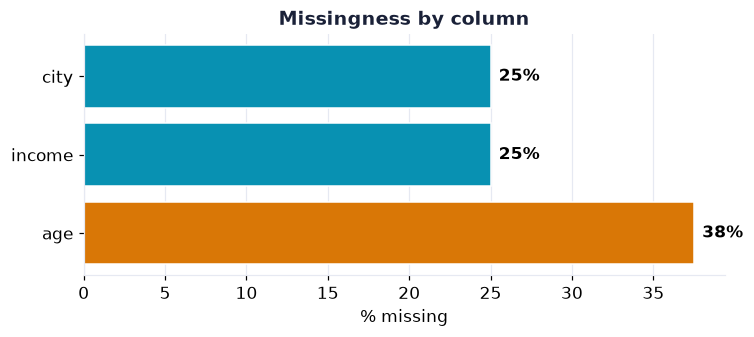

(missingno is a nice optional library for richer missingness maps: pip install missingno)


In [2]:
raw = pd.DataFrame({
    "age":    [34, -99, 41, 29, -99, 52, 38, -99],   # -99 = "not given"
    "income": [55, 62, np.nan, 48, 71, np.nan, 60, 90],
    "city":   ["NY","LA","N/A","SF","NY","N/A","LA","SF"],
})
df = raw.replace([-99, "N/A"], np.nan)               # sentinels -> real NaN FIRST

print("missing per column:"); print(df.isna().sum())
print("\npercent missing:"); print((df.isna().mean()*100).round(1))

pct = (df.isna().mean()*100)
fig, ax = plt.subplots(figsize=(7, 3.2))
colors = [AMBER if v>=30 else CYAN for v in pct.values]
ax.barh(pct.index, pct.values, color=colors, edgecolor="white")
ax.set_xlabel("% missing"); ax.set_title("Missingness by column"); ax.grid(axis="y", visible=False)
for i,v in enumerate(pct.values): ax.text(v+0.5, i, f"{v:.0f}%", va="center", fontweight="bold")
plt.tight_layout(); plt.show()
print("(missingno is a nice optional library for richer missingness maps: pip install missingno)")

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE COST OF DELETION</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🗑️ "Just drop the NaNs" is rarely free</div>
<div style="color:#4a5578;margin-top:6px">Listwise deletion (dropna) keeps only complete rows. It is unbiased only if data is MCAR, and even then it can throw away a lot. Always measure the loss before reaching for it.</div>
</div>

In [3]:
before = len(df)
complete = df.dropna()
print(f"rows before: {before}")
print(f"rows after dropna(): {len(complete)}  (lost {before-len(complete)} = {100*(before-len(complete))/before:.0f}%)")

# thresh keeps rows with at least N non-null values; subset only checks chosen columns
print(f"\ndropna(thresh=2) keeps rows with >=2 non-null: {len(df.dropna(thresh=2))} rows")
print(f"dropna(subset=['age']) only drops where age is missing: {len(df.dropna(subset=['age']))} rows")
print("\nUnder MAR/MNAR, dropping rows BIASES results, not just weakens them.")

rows before: 8
rows after dropna(): 3  (lost 5 = 62%)

dropna(thresh=2) keeps rows with >=2 non-null: 6 rows
dropna(subset=['age']) only drops where age is missing: 5 rows

Under MAR/MNAR, dropping rows BIASES results, not just weakens them.


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · MEAN IMPUTATION LIES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📉 It quietly shrinks the variance</div>
<div style="color:#4a5578;margin-top:6px">Mean imputation is the quick baseline everyone reaches for, and it distorts the data: every gap becomes the same value, so the standard deviation drops and a fake spike appears at the mean. Use it knowingly, never for careful inference.</div>
</div>

true SD (complete data)     : 15.82
SD of observed (NaNs dropped): 15.69
SD AFTER mean imputation     : 12.65   <- shrunk!


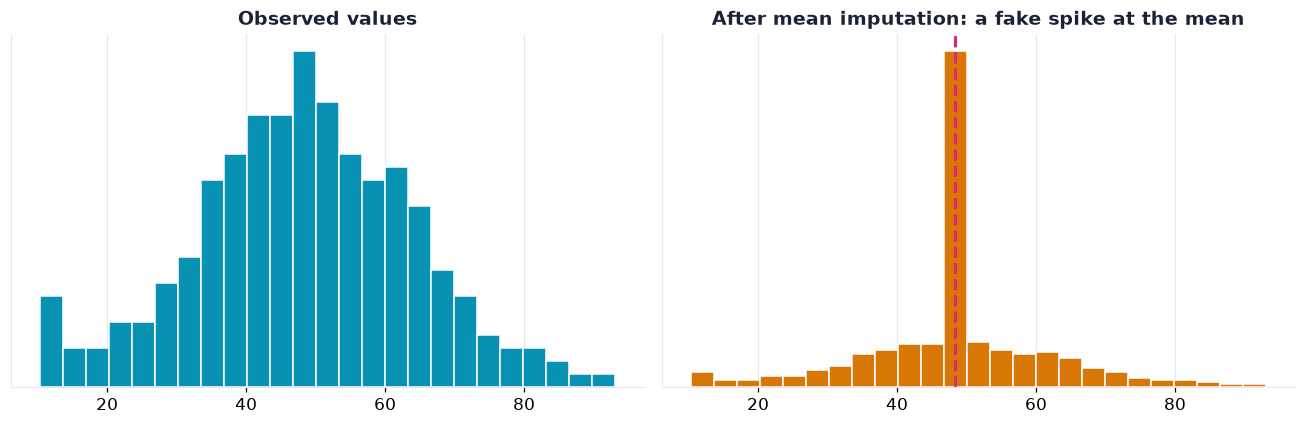

For skewed columns use median; but no single-value fill captures the real spread.


In [4]:
full = rng.normal(50, 15, 400)
observed = full.copy()
miss_idx = rng.choice(400, size=140, replace=False)    # 35% missing
observed[miss_idx] = np.nan

imp = SimpleImputer(strategy="mean")
filled = imp.fit_transform(observed.reshape(-1,1)).ravel()

print(f"true SD (complete data)     : {full.std():.2f}")
print(f"SD of observed (NaNs dropped): {np.nanstd(observed):.2f}")
print(f"SD AFTER mean imputation     : {filled.std():.2f}   <- shrunk!")

fig, (a1,a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(observed[~np.isnan(observed)], bins=25, color=CYAN, edgecolor="white")
a1.set_title("Observed values"); a1.set_yticks([])
a2.hist(filled, bins=25, color=AMBER, edgecolor="white")
a2.axvline(np.nanmean(observed), color=PINK, lw=2, ls="--")
a2.set_title("After mean imputation: a fake spike at the mean"); a2.set_yticks([])
plt.tight_layout(); plt.show()
print("For skewed columns use median; but no single-value fill captures the real spread.")

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · SMARTER IMPUTATION</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧩 KNN and MICE use the other columns</div>
<div style="color:#4a5578;margin-top:6px">Better imputers borrow strength from correlated columns. KNN fills from similar rows (standardize FIRST, since distance is scale-sensitive). MICE-style iterative imputation models each column from all the others and cycles to convergence, the serious default under MAR.</div>
</div>

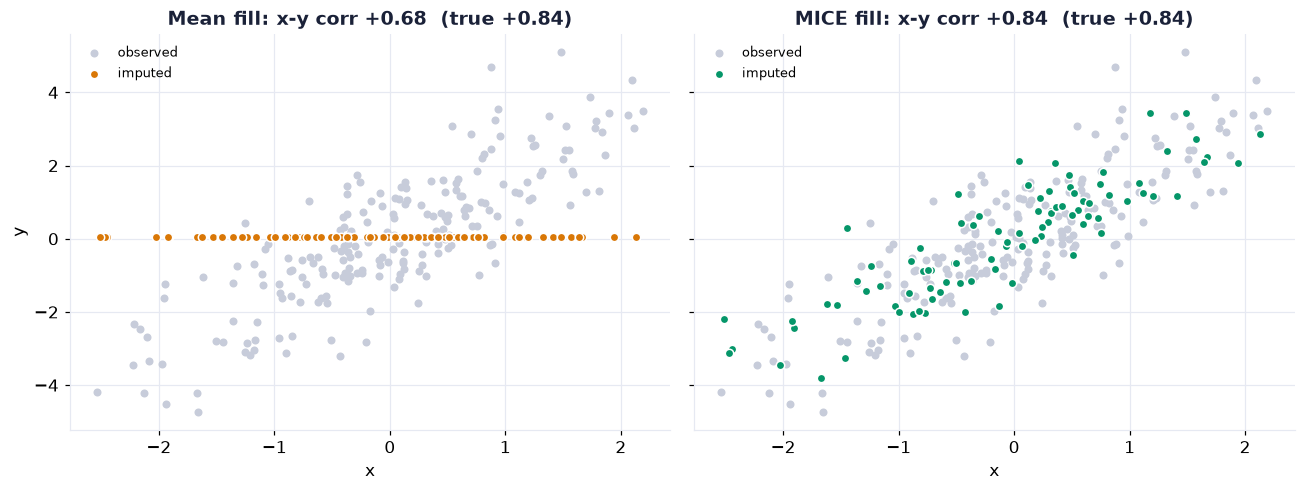

any NaN left after KNN / MICE? False / False
Mean fill stacks the imputed y on a flat line and flattens the x-y correlation;
MICE (and KNN) estimate y from x and z, so the imputed points follow the real trend.
Note: sklearn IterativeImputer is experimental and does SINGLE imputation; true multiple imputation pools many runs.


In [5]:
# x and z are complete predictors; y carries the gaps (so the scatter stays clean)
n = 300
x = rng.normal(0, 1, n)
z = rng.normal(0, 1, n)
y = 1.5*x - 0.8*z + rng.normal(0, 0.5, n)        # y truly depends on x and z
data = pd.DataFrame({"x": x, "z": z, "y": y})
ymask = np.zeros(n, dtype=bool); ymask[rng.choice(n, 90, replace=False)] = True
data.loc[ymask, "y"] = np.nan                     # 30% of y missing
true_corr = np.corrcoef(x, y)[0, 1]
ycol = data.columns.get_loc("y")

import warnings; from sklearn.exceptions import ConvergenceWarning
mean_y = data["y"].mean()
mean_fill = np.where(ymask, mean_y, data["y"].to_numpy())
mice = IterativeImputer(max_iter=20, random_state=0)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)   # tiny demo data may not fully converge
    mice_fill = mice.fit_transform(data)[:, ycol]          # uses x AND z to estimate y
# KNN also fills it (scale first); reported below
knn = Pipeline([("scale", StandardScaler()), ("impute", KNNImputer(n_neighbors=5))])
knn_fill = knn.fit_transform(data)[:, ycol]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True, sharey=True)
for ax, fill, name, c in [(a1, mean_fill, "Mean fill", AMBER), (a2, mice_fill, "MICE fill", GREEN)]:
    ax.scatter(x[~ymask], data["y"].to_numpy()[~ymask], s=18, color="#c7ccda", label="observed")
    ax.scatter(x[ymask], fill[ymask], s=30, color=c, edgecolor="white", label="imputed")
    ax.set_title(f"{name}: x-y corr {np.corrcoef(x, fill)[0,1]:+.2f}  (true {true_corr:+.2f})")
    ax.set_xlabel("x"); ax.legend(loc="upper left", fontsize=8.5)
a1.set_ylabel("y")
plt.tight_layout(); plt.show()

print(f"any NaN left after KNN / MICE? {np.isnan(knn_fill).any()} / {np.isnan(mice_fill).any()}")
print("Mean fill stacks the imputed y on a flat line and flattens the x-y correlation;")
print("MICE (and KNN) estimate y from x and z, so the imputed points follow the real trend.")
print("Note: sklearn IterativeImputer is experimental and does SINGLE imputation; true multiple imputation pools many runs.")

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · NO LEAKAGE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🚰 Fit the imputer on train only</div>
<div style="color:#4a5578;margin-top:6px">Same discipline as scaling in Chapter 12: learn the fill values from the TRAINING data, then apply them to the test data. Computing the mean over the whole dataset before splitting leaks test information into training and flatters your scores.</div>
</div>

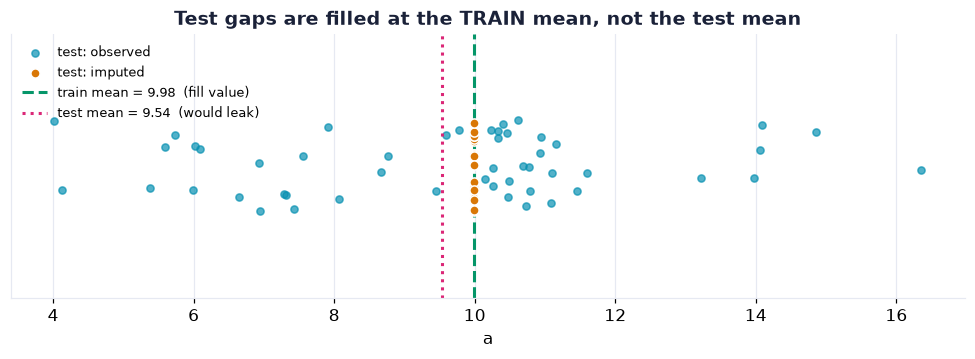

fill value learned from train : 9.98
test observed mean (NOT used) : 9.54
Imputed test points sit exactly on the green train-mean line, proof that no test data leaked in.
Best practice: put the imputer in a Pipeline so fit-on-train-only happens automatically in cross-validation.


In [6]:
X = pd.DataFrame({"a": rng.normal(10, 3, 240)})
X.loc[rng.choice(240, 70, replace=False), "a"] = np.nan
X_train, X_test = train_test_split(X, test_size=0.30, random_state=0)

imp = SimpleImputer(strategy="mean").fit(X_train)        # learn the mean from TRAIN only
train_mean = imp.statistics_[0]
test_obs_mean = X_test["a"].mean()                       # what a LEAKY fit would have used
a_test = X_test["a"].to_numpy(); test_mask = np.isnan(a_test)
filled = imp.transform(X_test).ravel()                    # test gaps filled with the TRAIN mean

fig, ax = plt.subplots(figsize=(9, 3.4))
jit = rng.uniform(-0.35, 0.35, len(a_test))
ax.scatter(a_test[~test_mask], jit[~test_mask], s=22, color=CYAN, alpha=0.7, label="test: observed")
ax.scatter(filled[test_mask], jit[test_mask], s=36, color=AMBER, edgecolor="white", zorder=5, label="test: imputed")
ax.axvline(train_mean,    color=GREEN, lw=2, ls="--", label=f"train mean = {train_mean:.2f}  (fill value)")
ax.axvline(test_obs_mean, color=PINK,  lw=2, ls=":",  label=f"test mean = {test_obs_mean:.2f}  (would leak)")
ax.set_yticks([]); ax.set_xlabel("a"); ax.set_ylim(-1, 1)
ax.set_title("Test gaps are filled at the TRAIN mean, not the test mean"); ax.grid(axis="y", visible=False)
ax.legend(loc="upper left", fontsize=8.2)
plt.tight_layout(); plt.show()

print(f"fill value learned from train : {train_mean:.2f}")
print(f"test observed mean (NOT used) : {test_obs_mean:.2f}")
print("Imputed test points sit exactly on the green train-mean line, proof that no test data leaked in.")
print("Best practice: put the imputer in a Pipeline so fit-on-train-only happens automatically in cross-validation.")

## 🕳️ Real-World Example: A Survey with Gaps
This survey has income **missing not at random**, higher earners are the ones who skip it. First we map where the gaps are, then we compare imputation strategies. The catch: because the missingness is tied to the hidden value, every simple fill inherits the same downward bias, so a missing-indicator flag (which preserves the fact that a value was absent) is part of the honest answer.

missing per column:
respondent_id      0
age               12
region             0
hours_online      21
income           101

income missing rate: 29%
observed (listwise) mean : $56,992
mean-imputed dataset mean: $56,992   (unchanged, mean-fill cannot fix MNAR bias)
median-imputed dataset mean: $57,283
Because income is MNAR, the observed mean is already biased low; add a missing-indicator flag to keep the signal.


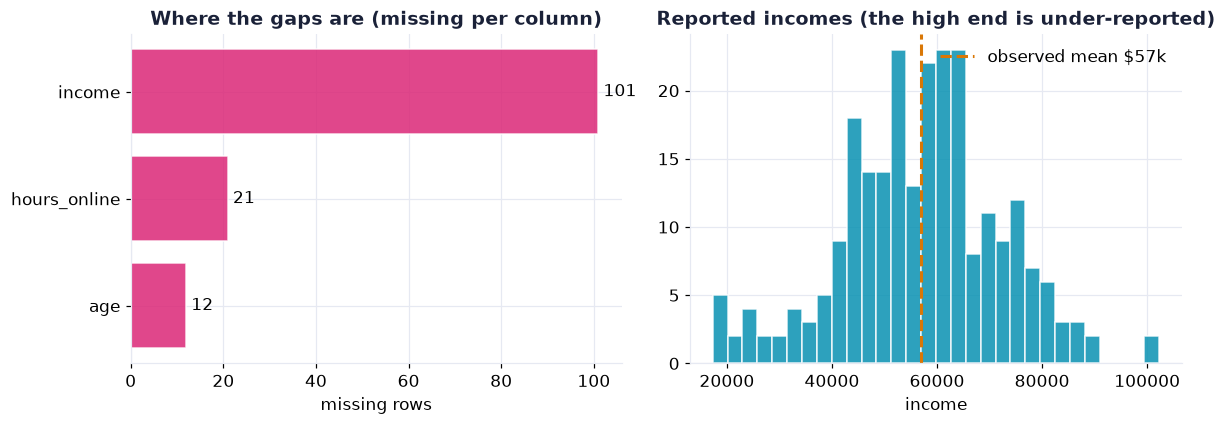

In [7]:
# --- Real-World beat: map the gaps, compare imputations, mind the MNAR bias ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    survey = pd.read_excel("../../data/ch20_survey_missing.xlsx", sheet_name="Data")
except FileNotFoundError: survey = pd.read_excel(BASE+"ch20_survey_missing.xlsx", sheet_name="Data")
print("missing per column:"); print(survey.isna().sum().to_string())
inc = survey.income
print(f"\nincome missing rate: {inc.isna().mean():.0%}")
print(f"observed (listwise) mean : ${inc.mean():,.0f}")
print(f"mean-imputed dataset mean: ${inc.fillna(inc.mean()).mean():,.0f}   (unchanged, mean-fill cannot fix MNAR bias)")
print(f"median-imputed dataset mean: ${inc.fillna(inc.median()).mean():,.0f}")
print("Because income is MNAR, the observed mean is already biased low; add a missing-indicator flag to keep the signal.")
fig, ax = plt.subplots(1, 2, figsize=(11,4))
miss = survey.isna().sum(); miss = miss[miss>0].sort_values()
ax[0].barh(miss.index, miss.values, color=PINK, alpha=0.85, edgecolor="white")
for i,v in enumerate(miss.values): ax[0].text(v, i, f" {v}", va="center")
ax[0].set_title("Where the gaps are (missing per column)"); ax[0].set_xlabel("missing rows")
ax[1].hist(inc.dropna(), bins=30, color=CYAN, alpha=0.85, edgecolor="white")
ax[1].axvline(inc.mean(), color=AMBER, ls="--", lw=2, label=f"observed mean ${inc.mean()/1000:.0f}k")
ax[1].set_title("Reported incomes (the high end is under-reported)"); ax[1].set_xlabel("income"); ax[1].legend()
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Convert hidden codes to NaN first</b>, then count and visualize missingness per column.</li>
<li><b>Deletion</b> (dropna) is unbiased only under MCAR and can discard a lot; under MAR/MNAR it biases results.</li>
<li><b>Mean imputation shrinks variance</b> and biases correlations; it is a baseline, not a careful answer.</li>
<li><b>KNN</b> (scale first) and <b>MICE</b> borrow strength from other columns; single imputation still understates uncertainty.</li>
<li><b>Fit imputers on train only</b> to avoid leakage; the mechanism (MCAR/MAR/MNAR) dictates the method.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>